In [6]:
"""Two separate, equally sized figures: EP loss fraction + sum_rho Delta_res(rho).

Fig (a): vs Bcrit (beta = 0 equilibrium)
        blue   -- firm3d loss fraction, figure6-13_loss_vs_Bcrit/data
        orange -- DESC sum_rho Delta_res(rho), figure6-13_loss_vs_Bcrit/desc_data
                  (produced by figure6-13_loss_vs_Bcrit/compute_delta_res_vs_Bcrit.py)
Fig (b): vs beta at fixed Bcrit = 6.24 T
        blue   -- firm3d loss fraction, figure13_loss_vs_beta/data
        orange -- DESC sum_rho Delta_res(rho), figure13_loss_vs_beta/desc_data

Styling follows lossfrac_rerun/plot_lossfrac_figures.ipynb (Times New Roman,
twin axes coloured blue/orange).
"""


'Two separate, equally sized figures: EP loss fraction + sum_rho Delta_res(rho).\n\nFig (a): vs Bcrit (beta = 0 equilibrium)\n        blue   -- firm3d loss fraction, figure6-13_loss_vs_Bcrit/data\n        orange -- DESC sum_rho Delta_res(rho), figure6-13_loss_vs_Bcrit/desc_data\n                  (produced by figure6-13_loss_vs_Bcrit/compute_delta_res_vs_Bcrit.py)\nFig (b): vs beta at fixed Bcrit = 6.24 T\n        blue   -- firm3d loss fraction, figure13_loss_vs_beta/data\n        orange -- DESC sum_rho Delta_res(rho), figure13_loss_vs_beta/desc_data\n\nStyling follows lossfrac_rerun/plot_lossfrac_figures.ipynb (Times New Roman,\ntwin axes coloured blue/orange).\n'

In [7]:
import glob
import os

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

HERE = os.path.abspath(".")          # run this notebook from figure_combined/
ROOT = os.path.dirname(HERE)
BCRIT_DIR = os.path.join(ROOT, "figure6-13_loss_vs_Bcrit")
BETA_DIR = os.path.join(ROOT, "figure13_loss_vs_beta")
STEM = "wout_v20250319_v3_LowShear_000_000000_desc"
BETAS = [0.002, 0.004, 0.006, 0.008, 0.01]


In [8]:
# --- panel (a): vs Bcrit -----------------------------------------------------
(path,) = glob.glob(os.path.join(BCRIT_DIR, "data", "*_loss_fraction_vs_Bcrit.txt"))
loss_data_a = np.loadtxt(path)
Bcrit_a = np.linspace(4.5, 7.8, 40)
desc_a = np.loadtxt(os.path.join(BCRIT_DIR, "desc_data", "sum_delta_res_vs_Bcrit.txt"))
pitch_inv_a, sum_delta_res_a = desc_a[:, 0], desc_a[:, 1]

# --- panel (b): vs beta ------------------------------------------------------
loss_frac_b = [
    float(np.atleast_2d(
        np.loadtxt(os.path.join(BETA_DIR, "data", f"{STEM}_{b}_loss_fraction_vs_Bcrit.txt"))
    )[-1, -1])
    for b in BETAS
]
desc_b = np.loadtxt(os.path.join(BETA_DIR, "desc_data", "sum_delta_res_vs_beta.txt"))
beta_pct = desc_b[:, 0] * 100.0
sum_delta_res_b = desc_b[:, 1]


In [9]:
# --- style -------------------------------------------------------------------
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)

# Two separate figures of identical size, with identical axes boxes.
FIGSIZE = (6, 5)
AXES_MARGINS = dict(left=0.17, right=0.82, bottom=0.18, top=0.97)


def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)


def save(fig, stem):
    for ext in ("pdf", "png"):
        out = os.path.join(HERE, f"{stem}.{ext}")
        fig.savefig(out, dpi=300)
        print("wrote", out)


wrote /Users/paullab/Papers/TRObj2026/T1E_rerun/figure_combined/loss_frac_vs_Bcrit.pdf
wrote /Users/paullab/Papers/TRObj2026/T1E_rerun/figure_combined/loss_frac_vs_Bcrit.png


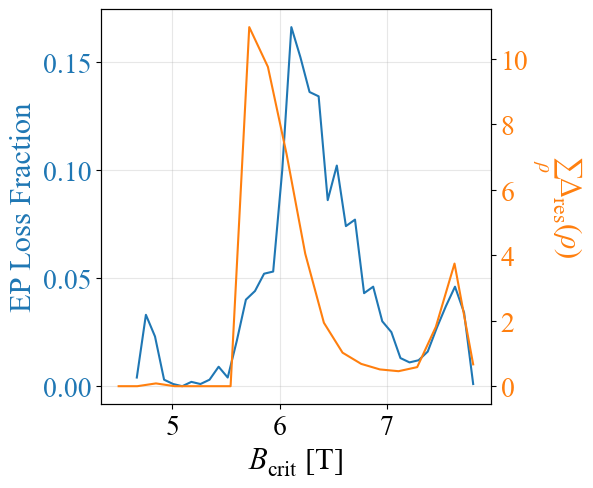

In [10]:
c_blue, c_orange = "tab:blue", "tab:orange"

# --- figure (a): loss fraction and sum_rho Delta_res vs Bcrit ----------------
fig_a, ax_a = plt.subplots(figsize=FIGSIZE)
ax_a_r = ax_a.twinx()

ax_a.plot(Bcrit_a, loss_data_a[:, -1], color=c_blue, label="loss fraction")
ax_a.set_ylabel("EP Loss Fraction", color=c_blue, **label_kw)
ax_a.tick_params(axis="y", labelcolor=c_blue, labelsize=tick_labelsize)
ax_a.set_xlabel(r"$B_{\mathrm{crit}}~$[T]", **label_kw)
ax_a.tick_params(axis="x", labelsize=tick_labelsize)
ax_a.grid(True, alpha=0.3)

ax_a_r.plot(pitch_inv_a, sum_delta_res_a, color=c_orange)
ax_a_r.set_ylabel(r"$\sum_{\rho} \Delta_{\mathrm{res}}(\rho)$", color=c_orange,
                  rotation=270, labelpad=40, **label_kw)
ax_a_r.tick_params(axis="y", labelcolor=c_orange, labelsize=tick_labelsize)

apply_standard_axes(fig_a)
save(fig_a, "loss_frac_vs_Bcrit")


wrote /Users/paullab/Papers/TRObj2026/T1E_rerun/figure_combined/loss_frac_vs_beta.pdf
wrote /Users/paullab/Papers/TRObj2026/T1E_rerun/figure_combined/loss_frac_vs_beta.png


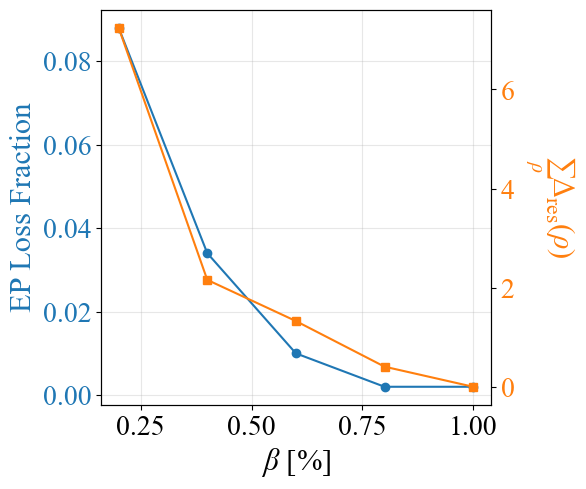

In [11]:
# --- figure (b): loss fraction and sum_rho Delta_res vs beta (Bcrit = 6.24 T) -
fig_b, ax_b = plt.subplots(figsize=FIGSIZE)
ax_b_r = ax_b.twinx()

ax_b.plot(beta_pct, loss_frac_b, "o-", color=c_blue)
ax_b.set_ylabel("EP Loss Fraction", color=c_blue, **label_kw)
ax_b.tick_params(axis="y", labelcolor=c_blue, labelsize=tick_labelsize)
ax_b.set_xlabel(r"$\beta$ [%]", **label_kw)
ax_b.tick_params(axis="x", labelsize=tick_labelsize)
ax_b.grid(True, alpha=0.3)

ax_b_r.plot(beta_pct, sum_delta_res_b, "s-", color=c_orange)
ax_b_r.set_ylabel(r"$\sum_{\rho} \Delta_{\mathrm{res}}(\rho)$", color=c_orange,
                  rotation=270, labelpad=45, **label_kw)
ax_b_r.tick_params(axis="y", labelcolor=c_orange, labelsize=tick_labelsize)

apply_standard_axes(fig_b)
save(fig_b, "loss_frac_vs_beta")
